RQ3 

Facemask wearing - Early pandemic 

Feature Importance 

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import joblib


Feature Importance                              Feature  Importance
10                    mandate_period    0.177450
9               7days_rolling_deaths    0.145896
6   protective_behavior_nomask_scale    0.105256
8                7days_rolling_cases    0.101581
24                    state_Victoria    0.100389
7                               week    0.054549
1                                age    0.040977
0             Non-household contacts    0.036678
4                 Perceived Severity    0.034854
19             state_New South Wales    0.031450
21                  state_Queensland    0.025817
5           Perceived Susceptibility    0.015552
3                          Wellbeing    0.014724
25           state_Western Australia    0.012163
2                     household_size    0.009460


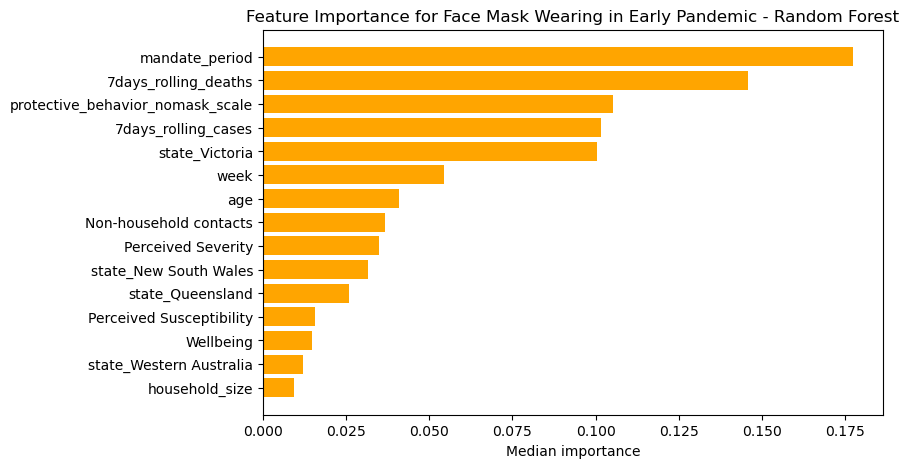

In [ ]:
# downloadig data from the rf model code

# face mask early  train set

early_train_facemask = pd.read_csv("early_train_facemask.csv")

# remove the target variables and identifiers
drop_cols = ['RecordNo', 'Date', 'face_mask_scale', 'face_mask_binary','general_protective_behavior_scale',
                'general_protective_behavior_binary','mandate_start_date', 'wave'] # wave 




# predictors
x_train = early_train_facemask.drop(columns=drop_cols)
x_train = x_train.astype(float)  # converting boolean to float 


# target variable
y_train = early_train_facemask["face_mask_binary"]


# best rf hyper parameters
best_parameters = joblib.load(f"RQ3_facemask_early_RF_bestParameters_rolling.pkl")




# feature importance 


# to keep all the importances in each run
all_importances = []



# 100 runs for stability 
for i in range(100): 

    temp_rf = Pipeline([
        ('ros', RandomOverSampler(random_state=i)),
        ('rf', RandomForestClassifier(random_state=i,
                                      n_jobs=-1))
                                      ])

    temp_rf.set_params(**best_parameters)

    temp_rf.fit(x_train, y_train)

    all_importances.append(temp_rf.named_steps["rf"].feature_importances_)




all_importances = np.array(all_importances)

# take the median 
median_importance = np.median(all_importances, axis=0) # take the median of each column(feature) 


feature_importance = pd.DataFrame({
        "Feature": x_train.columns,
        "Importance": median_importance
    })

feature_importance = feature_importance.sort_values("Importance",ascending=False)



top15 = feature_importance.head(15)

print(f"Feature Importance",top15)

feature_importance.to_csv(f"RQ3_facemask_early_RF_FeatureImportance_rolling.csv",index=False) # full feature importance list


# plot
plt.figure(figsize=(8,5))
plt.barh(top15["Feature"], top15["Importance"], color="orange")
plt.title(f"Feature Importance for Face Mask Wearing in Early Pandemic - Random Forest")
plt.xlabel("Median importance")
plt.gca().invert_yaxis()
plt.savefig(f"RQ3_facemask_early_RF_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")
plt.show()
